# Class 19: Astropy: Time, Observation Planning, and FITS Files
## Objective: Learn how to plan astronomical observations

Observations planning requires information about the observation date, location of the Observatory (if on Earth), and target coordinates. Details like the times of sunrise and sunset, and the potential location of the mooon throughout the night, require both detailed time calculations and orbital information. The visibility of a target depends on the celestial coordinates, location of the Observatory, and time, and potentially orbital information (e.g. for Solar System objects). 

The `astropy` package has great tools to help with these complex calculations. There is also a package called `astroplan` that provides additional functionality. 

You will likely have to use conda to install astroplan. You can do this in the same way as you installed astroquery for the previous lecture:

`conda install -c astropy astroplan`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, get_body
from astropy.time import Time
import datetime
import astropy.units as u
from astroquery.simbad import Simbad
from astroplan import Observer, FixedTarget
from astropy.visualization import astropy_mpl_style, quantity_support

# Set display options for better visibility
pd.set_option('display.max_rows', 100)      # Show up to 100 rows before truncating
pd.set_option('display.max_columns', 20)    # Show up to 20 columns before truncating
pd.set_option('display.width', 120)         # Wider display for more columns
pd.set_option('display.precision', 3)       # Show 3 decimal places
pd.set_option('display.float_format', '{:.3f}'.format)  # Consistent float formatting

## Section 1: Handling Time in Astronomy (astropy.time)

Observations in astronomy depend on the Earth’s motion and light travel time, so we use high-precision formats like Julian Date (JD) and Modified Julian Date (MJD). The `astropy.time` module allows us to convert between these formats and different scales (like UTC or TAI) seamlessly. (UTC is Coordinated Universal Time, TAI is Temps Atomique International or International Atomic Time.)

In [2]:
def print_current_times():
    """
    Retrieves the current system time and returns it in various 
    astronomical formats.
    """
    # Get current time from system
    current_time = Time.now()
    
    # Create a dictionary of different variations
    variations = {
        "ISO": current_time.iso, # international standard
        "ISOT": current_time.isot, # adds a T between date and time in ISO
        "Julian Date": current_time.jd,
        "Modified Julian Date": current_time.mjd,
        "Unix Timestamp": current_time.unix # seconds since Jan 1, 1970 (UTC)
    }
    
    # Print the variations for reference
    print(f"Current System Time (UTC): {current_time}\n")
    for label, value in variations.items():
        print(f"{label:20}: {value}")
        
    return variations

# Run the function
time_data = print_current_times()

Current System Time (UTC): 2026-02-25 19:34:52.051530

ISO                 : 2026-02-25 19:34:52.052
ISOT                : 2026-02-25T19:34:52.052
Julian Date         : 2461097.315880226
Modified Julian Date: 61096.815880226044
Unix Timestamp      : 1772048092.05153


**Test your understanding:** 
Look at the output of `datetime.datetime.now()` and research how to add the current time in our local time to the function above.
*Hint: You can get timezone info with the .astimezone() method and the .tzinfo attribute.*

In [19]:
current_time = Time.now()
print(datetime.datetime.now())
# Enter your code here 
current_time.astimezone()

2026-02-25 14:58:03.041044
2026-02-25 19:58:03.039241


AttributeError: module 'datetime' has no attribute 'now'

## Section 2: Defining Observer Locations

To plan an observation, you must tell python where you are on Earth. The `EarthLocation` class in `astropy.coordinates` allows you to define a site using latitude, longitude, and elevation. This is critical for calculating when a star will rise or set at your specific observatory.

In [5]:
# Define the location for Columbus, OH
columbus = EarthLocation(lat=40.0*u.deg, lon=-83.0*u.deg, height=200*u.m)

# You can also use built-in site names
lbt = EarthLocation.of_site('Large Binocular Telescope')
print(f"LBT Geodetic Coordinates: {lbt.geodetic}")

LBT Geodetic Coordinates: GeodeticLocation(lon=<Longitude -109.8719 deg>, lat=<Latitude 32.7016 deg>, height=<Quantity 2902. m>)


**Test your understanding**
Use EarthLocation.of_site() to find the coordinates of 'Kitt Peak National Observatory'. Print its longitude in degrees.

In [17]:
# Your code here
kpno = EarthLocation.of_site('Kitt Peak National Observatory')
print(kpno.geodetic)

GeodeticLocation(lon=<Longitude -111.6 deg>, lat=<Latitude 31.96333333 deg>, height=<Quantity 2120. m>)


## Section 3: Observation Planning with `astroplan`

Observation planning involves calculating a target's visibility based on Airmass and Altitude. Airmass measures how much atmosphere you are looking through. An airmass of 1.0 is directly overhead, while higher values (like 2.0, which is an Altitude of 30 degrees above the horizon) indicate the object is closer to the horizon, leading to poorer data quality.

In [10]:
target_name = "Sagittarius A*" # Try your favorite object! 

# Use astroquery to query SIMBAD for the target coordinates
result_table = Simbad.query_object(target_name) # the result is an astropy Table

# Extract RA and Dec strings from the table
ra_str = result_table['RA'][0]
dec_str = result_table['DEC'][0]

# Create a SkyCoord object from the SIMBAD results
target_coords = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg), frame='icrs')

print(f"Coordinates for {target_name} from SIMBAD: {target_coords.ra.deg:.6f}, {target_coords.dec.deg:.6f}")

# Set up the Observation location
columbus = EarthLocation(lat=40.0*u.deg, lon=-83.0*u.deg, height=200*u.m)
obs = Observer(location=columbus, name="Columbus, OH")

# Wrap the SkyCoord into a FixedTarget
target = FixedTarget(coord=target_coords, name=target_name)

# Determine Visibility
current_time = Time.now()

is_up = obs.target_is_up(current_time, target)
alt_az = obs.altaz(current_time, target)

print(f"\nObservation Time (UTC): {current_time.iso}")
print(f"Is {target_name} above the horizon? {is_up}")
print(f"Current Altitude: {alt_az.alt:.2f}")

Coordinates for Sagittarius A* from SIMBAD: 266.416816, -29.007825

Observation Time (UTC): 2026-02-25 19:42:22.532
Is Sagittarius A* above the horizon? False
Current Altitude: -26.41 deg


### Visualization

The previous code returned useful information, although it only tells us whether our target is currently above the horizon (and by how much). 

It is much more useful to know if it is observable at night, and if so how far it is above the horizon as a function of time. 

The following code shows how to calculate the height of some targets above the horizon throughout the night, as well as the location of the Sun and Moon, and identify the times of sunrise, sunset, and astronomical twilight. 

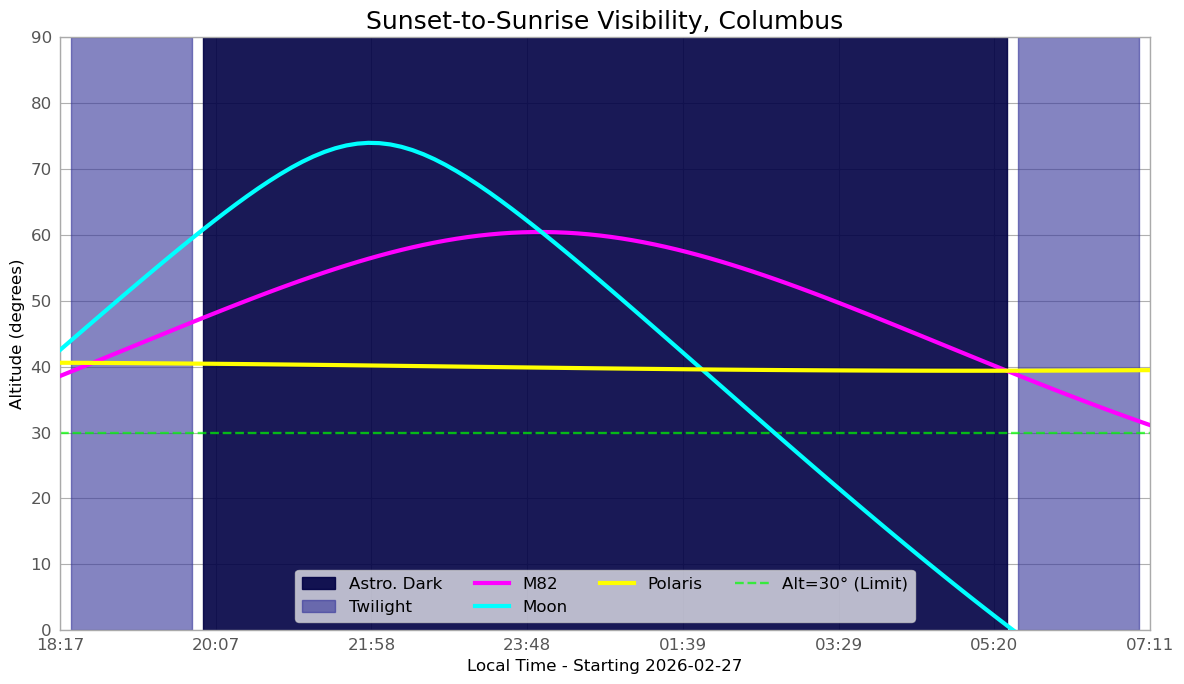

In [21]:
# Setup Styles
plt.style.use(astropy_mpl_style) # built-in style sheet that aligns with standard publication formats
quantity_support() # supports plotting astropy.units.Quantity instances

def get_skycoords(target_name):
    '''
    Get the coordinates of a named target with Simbad and return a SkyCoord object
    '''
    result_table = Simbad.query_object(target_name)
    if result_table is None:
        return None
    ra_str = result_table['RA'][0]
    dec_str = result_table['DEC'][0]
    return SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg), frame='icrs')

def check_major_body(name):
    '''
    Determine if a named target is a Solar System object
    This is useful because Solar System objects noticeably move during the night, especially the nearby ones
    '''
    major_bodies = ['sun', 'moon', 'mercury', 'venus', 'mars', 
                    'jupiter', 'saturn', 'uranus', 'neptune', 'pluto']
    return name.lower() in major_bodies

# Establish the targets
target_names = ["M82", "Moon", "Polaris"]  # Try others! 
targets = {}

# Get coordinates for targets or flag them as Solar System objects
for name in target_names:
    if not check_major_body(name):
        coords = get_skycoords(name)
        if coords: targets[name] = coords
    else:
        targets[name] = "SolarSystem" # Placeholder

# Configure the observing location
columbus = EarthLocation(lat=40.0*u.deg, lon=-83.0*u.deg, height=200*u.m)
local_now = datetime.datetime.now().astimezone()
offset_seconds = local_now.utcoffset().total_seconds()
utc_offset = (offset_seconds / 3600) * u.hour

# 3. Define the Observer
obs = Observer(location=columbus, name="Columbus")

# Get the current time 
now = Time.now()

# If run before noon, anchor to 'yesterday' to get the current ongoing night
# If run after noon, anchor to 'today' to get the upcoming night
current_local_hour = (now + utc_offset).datetime.hour
if current_local_hour < 12:
    anchor_time = now - 12 * u.hour
else:
    anchor_time = now

# Calculate the boundaries for this specific night
sunset = obs.sun_set_time(anchor_time, which='next')
sunrise = obs.sun_rise_time(sunset, which='next')

# Mid-night astronomical dark period (we'll shade night time on the plot)
astro_dark_start = obs.twilight_evening_astronomical(sunset, which='next')
astro_dark_end = obs.twilight_morning_astronomical(astro_dark_start, which='next')

# Time from sunset to sunrise
total_night_hours = (sunrise.mjd - sunset.mjd) * 24
hours_rel = np.linspace(0, total_night_hours, 100)
night_times = sunset + hours_rel * u.hour

# Local decimal hours for X-Axis
local_times = (night_times + utc_offset)
local_hours = (local_times.mjd % 1) * 24 

# Create frames and Sun position for shading
altaz_frames = AltAz(obstime=night_times, location=columbus)
sun_altaz = get_sun(night_times).transform_to(altaz_frames)

# Create the plot 
plt.figure(figsize=(12, 7))

# Define high-contrast colors for visibility
colors = ['#FF00FF', '#00FFFF', '#FFFF00', '#00FF00', '#FF3300']

# Shading: Astronomical Night (Sun < -18)
# Use 'hours_rel' for the x-axis to keep the plot continuous
plt.fill_between(hours_rel, 0, 90, sun_altaz.alt.deg <= -18,
                 color='#000044', alpha=0.9, label='Astro. Dark', zorder=1)

# Shading: Twilight (Sun between 0 and -18)
plt.fill_between(hours_rel, 0, 90, (sun_altaz.alt.deg > -18) & (sun_altaz.alt.deg <= 0),
                 color='#333399', alpha=0.6, label='Twilight', zorder=1)

# Plot targets with specific colors
for i, (name, coord) in enumerate(targets.items()):
    if coord == "SolarSystem":
        target_coords = get_body(name, night_times, columbus)
    else:
        target_coords = coord
    
    target_altaz = target_coords.transform_to(altaz_frames)
    
    # Use hours_rel for x-axis to prevent the 'Midnight Wrap' line-stretching bug
    plt.plot(hours_rel, target_altaz.alt.deg, 
             label=name, linewidth=3, color=colors[i % len(colors)], zorder=5)

# Format the X-Axis
# We map 'hours_rel' to 'local_hours' labels so it's readable but mathematically continuous
tick_indices = np.linspace(0, total_night_hours, 8)
tick_labels = [(sunset + utc_offset + h*u.hour).datetime.strftime('%H:%M') for h in tick_indices]

plt.xticks(tick_indices, tick_labels, fontsize=12)
plt.axhline(30, color='#00FF00', linestyle='--', alpha=0.7, label='Alt=30° (Limit)')
plt.ylim(0, 90)
plt.xlim(0, total_night_hours)

plt.xlabel(f'Local Time - Starting {sunset.iso[:10]}', fontsize=12)
plt.ylabel('Altitude (degrees)', fontsize=12)
plt.title(f'Sunset-to-Sunrise Visibility, {obs.name}', fontsize=18)
plt.legend(loc='lower center', ncol=4, framealpha=0.7, fontsize=12)

plt.tight_layout()
plt.show()

**Test your understanding:** Adapt this code to work for other days and other objects

In [ ]:
# Enter your code here

## Section 4: Working with FITS Files (astropy.io.fits)

FITS (Flexible Image Transport System) is the standard file format for astronomical images and tables. A FITS file consists of HDUs (Header Data Units). The Header contains metadata (telescope name, exposure time, coordinates), and the Data contains the actual pixel values or table entries.

First we will download a JWST image from the archive at the Space Telescope Science Institute.

In [29]:
import urllib.request
import os
import gzip
import shutil

fits_url = "https://archive.stsci.edu/hlsps/ceers/nircam/hlsp_ceers_jwst_nircam_nircam3_f200w_v0.5_i2d.fits.gz"
fits_gz = "ceers_nircam3_f200w.fits.gz"
fits_file = "ceers_nircam3_f200w.fits"

print(f"JWST CEERS NIRCam F200W Image")
print(f"="*60)
print(f"Source: MAST Archive (archive.stsci.edu)")
print(f"Survey: Cosmic Evolution Early Release Science (CEERS)")
print(f"Instrument: JWST/NIRCam")
print(f"Filter: F200W (2.0 microns)")
print(f"Field: Extended Groth Strip")
print(f"Compressed size: ~1.5 GB, Uncompressed: ~2.5 GB")
print(f"="*60)

# if not os.path.exists(fits_file):  # This only downloads the fits file if you haven't already done so
   # if not os.path.exists(fits_gz):
print(f"\nDownloading {fits_gz}...")
print(f"This will take several minutes depending on connection speed.\n")
try:
    urllib.request.urlretrieve(fits_url, fits_gz)
    print(f"\n✓ Downloaded {fits_gz}")
except Exception as e:
    print(f"\n✗ Download failed: {e}")
    print(f"\nAlternative: Visit https://archive.stsci.edu/hlsp/ceers")
    print(f"Download NIRCam pointing 3, F200W filter manually")
    fits_gz = None
 #   if os.path.exists(fits_gz):
print(f"\nDecompressing {fits_gz} (this may take a minute)...")
with gzip.open(fits_gz, 'rb') as f_in:
    with open(fits_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print(f"✓ Decompressed to {fits_file}")
os.remove(fits_gz)
print(f"Removed {fits_gz} (saved 1.5 GB disk space)")
#else:
print(f"\n{fits_file} already exists, so did not download it again")

if os.path.exists(fits_file):
    file_size_gb = os.path.getsize(fits_file) / (1024**3)
    print(f"\nReady to work with JWST data ({file_size_gb:.2f} GB)")

JWST CEERS NIRCam F200W Image
Source: MAST Archive (archive.stsci.edu)
Survey: Cosmic Evolution Early Release Science (CEERS)
Instrument: JWST/NIRCam
Filter: F200W (2.0 microns)
Field: Extended Groth Strip
Compressed size: ~1.5 GB, Uncompressed: ~2.5 GB

This will take several minutes depending on connection speed.


✓ Downloaded ceers_nircam3_f200w.fits.gz

Decompressing ceers_nircam3_f200w.fits.gz (this may take a minute)...
✓ Decompressed to ceers_nircam3_f200w.fits
Removed ceers_nircam3_f200w.fits.gz (saved 1.5 GB disk space)

ceers_nircam3_f200w.fits already exists, so did not download it again

Ready to work with JWST data (2.25 GB)


In [31]:
# Now check the image
from astropy.io import fits

if os.path.exists(fits_file):
    hdulist = fits.open(fits_file)
    print(f"FITS file structure:")
    print(f"="*60)
    hdulist.info()
    print(f"="*60)
    print(f"\nThe file contains {len(hdulist)} HDUs (Header-Data Units)")
else:
    print(f"File {fits_file} not found.")

if os.path.exists(fits_file):
    # Extract primary HDU (Header Data Unit)
    primary = hdulist[0]
    header = primary.header
    
    # Read key metadata from header using .get() for safe access
    print(f"Key Observation Information:")
    print(f"="*60)
    print(f"Telescope:        {header.get('TELESCOP', 'N/A')}")
    print(f"Instrument:       {header.get('INSTRUME', 'N/A')}")
    print(f"Filter:           {header.get('FILTER', 'N/A')}")
    print(f"Observation date: {header.get('DATE-OBS', 'N/A')}")
    print(f"Total exposure:   {header.get('TEXPTIME', 0):.1f} seconds")
    print(f"Data units:       {header.get('BUNIT', 'N/A')}")
    print(f"Target field:     {header.get('TARGPROP', 'EGS Field')}")
    print(f"Image size:       {header.get('NAXIS1', 0)} × {header.get('NAXIS2', 0)} pixels")
    print(f"="*60)

FITS file structure:
Filename: ceers_nircam3_f200w.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     374   ()      
  1  SCI_BKSUB     1 ImageHDU        76   (10500, 4800)   float64   
  2  SCI           1 ImageHDU        75   (10500, 4800)   float32   
  3  ERR           1 ImageHDU        10   (10500, 4800)   float32   
  4  CON           1 ImageHDU         9   (10500, 4800)   int32   
  5  WHT           1 ImageHDU         9   (10500, 4800)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (10500, 4800)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (10500, 4800)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (10500, 4800)   float32   
  9  BKGD          1 ImageHDU        39   (10500, 4800)   float64   
 10  BKGMASK       1 ImageHDU        39   (10500, 4800)   float32   
 11  HDRTAB        1 BinTableHDU    816   24R x 403C   [23A, 5A, 3A, 48A, 7A, 13A, 5A, 5A, 7A, 10A, 4A, L, D, D, D, D, 4A, 18A, 57A, 22A, 3A, 

**Test your understanding:** What keyword has the exposure time? Which header has this information? 

In [ ]:
# Enter your answer

## Section 5: World Coordinate System (WCS)

The WCS is the part of a FITS header that maps pixel coordinates (x, y) to physical sky coordinates (RA, Dec). Using astropy.wcs, we can convert a specific pixel in an image back to its exact location on the celestial sphere.

In [32]:
# Find the image data
if os.path.exists(fits_file):
    # Access image data array from primary HDU
    image_data = primary.data
    
    # Some FITS files store data in extension HDUs instead of primary
    if image_data is None:
        for i, hdu in enumerate(hdulist):
            if hdu.data is not None:
                print(f"Found image data in HDU {i}")
                image_data = hdu.data
                header = hdu.header
                break
    
    if image_data is not None:
        print(f"Image Data Properties:")
        print(f"="*60)
        print(f"Shape:     {image_data.shape} pixels")
        print(f"Data type: {image_data.dtype}")
        print(f"Size:      {image_data.nbytes / (1024**3):.2f} GB in memory")
        
        # Use np.nanmin/nanmax/etc to ignore NaN values in statistics
        print(f"\nStatistics (in MJy/sr):")
        print(f"  Minimum:     {np.nanmin(image_data):.6f}")
        print(f"  Maximum:     {np.nanmax(image_data):.6f}")
        print(f"  Median:      {np.nanmedian(image_data):.6f}")
        print(f"  Mean:        {np.nanmean(image_data):.6f}")
        print(f"  Std dev:     {np.nanstd(image_data):.6f}")
        n_nans = np.isnan(image_data).sum()
        print(f"\nNaN pixels:  {n_nans:,} ({100*n_nans/image_data.size:.2f}%)")
        print(f"="*60)
    else:
        print("Could not find image data in any HDU")


Found image data in HDU 1
Image Data Properties:
Shape:     (4800, 10500) pixels
Data type: >f8
Size:      0.38 GB in memory

Statistics (in MJy/sr):
  Minimum:     -1.950443
  Maximum:     350.751251
  Median:      0.000000
  Mean:        0.006953
  Std dev:     0.313088

NaN pixels:  0 (0.00%)


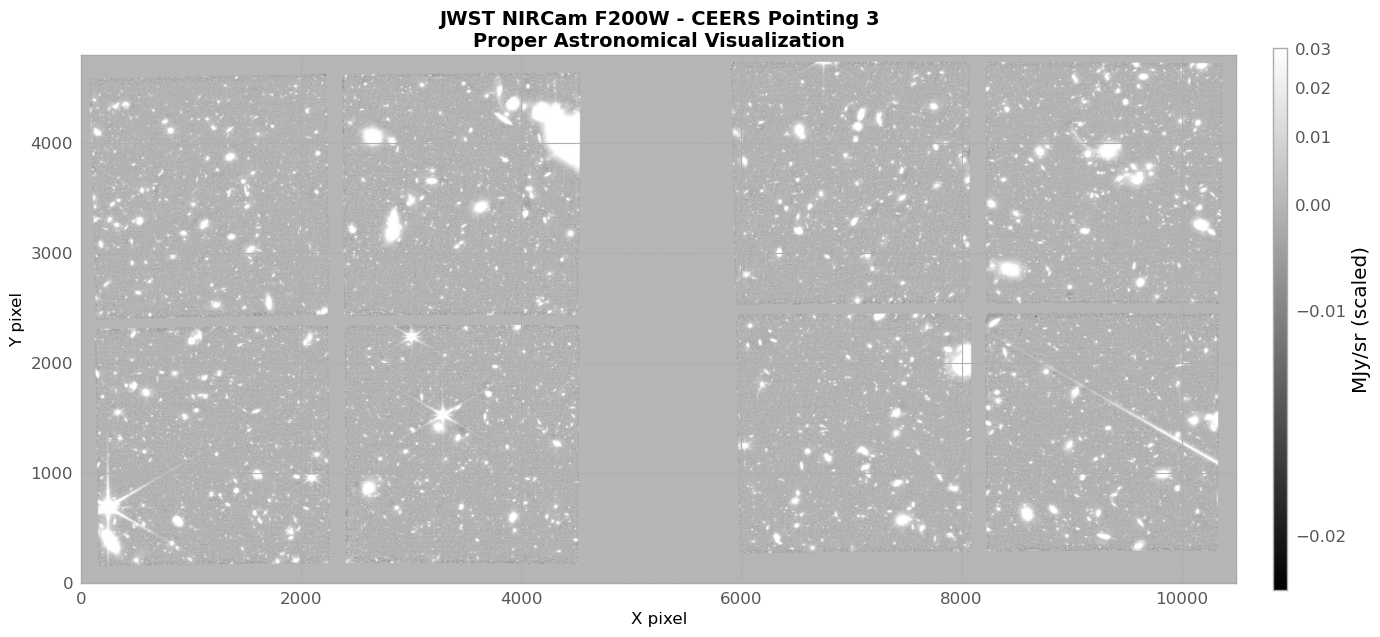

In [33]:
# Display the image
if os.path.exists(fits_file) and image_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(image_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = image_data.shape[0] / image_data.shape[1]
    fig_width = 14
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(image_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('JWST NIRCam F200W - CEERS Pointing 3\nProper Astronomical Visualization', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(fits_file):
    print("Skipping visualization - no image data loaded")

**Test your understanding:** Try a few alternative ways to display the image.